<a href="https://colab.research.google.com/github/Funmi36/Ecological-Stability-Modeling/blob/main/Ecological_Stability_Modeling_(Group_2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # **Ecological Stability Modeling: Predicting Extinction Thresholds in Prey-Predator Systems using Sensitivity Analysis**

## **Step 1**
###Creating the Lotka-volterra equation (Deterministic)


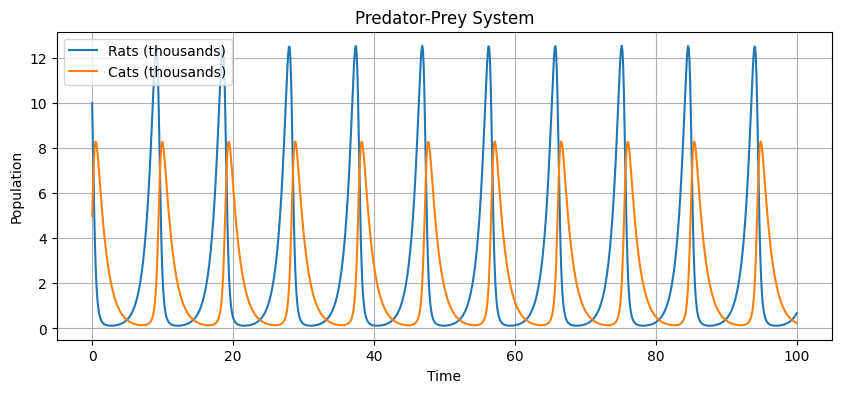

In [ ]:
# Importing useful libraries
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# prey is x, predator is y
initial_y = [10, 5]

# Time
t = np.linspace(0, 100, 1000)

# the parameters with environmental factor
alpha_base= 1.0 #prey growth rate
beta_base= 0.5 #predation rate
delta_base= 0.3 #predator death rate
gamma_base= 0.8 #conversion efficiency

def predator_prey_sytem(variables, t, alpha_base, beta_base, delta_base, gamma_base):

    x, y = variables

    dxdt = alpha_base * x - beta_base * x * y #prey population
    dydt = delta_base * x * y - gamma_base * y #Predator growth rate based on food consumption
    return([dxdt, dydt])


#The Lotka–Volterra predator–prey equations were numerically integrated using odeint to obtain the time evolution of prey and predator populations from specified initial conditions.
solution = odeint(predator_prey_sytem, initial_y, t, args= (alpha_base, beta_base, delta_base, gamma_base))

# Visualizing the system
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(t,solution[:,0], label= "Rats (thousands)")
ax.plot(t,solution[:,1], label = "Cats (thousands)")
ax.set_xlabel("Time")
ax.set_ylabel("Population")
ax.legend()
ax.set_title("Predator-Prey System")

plt.grid()
plt.show()

## **Step 2**
###Adding Environmental Factors (Stochasticity) and generating the dataset

In [ ]:
import numpy as np
import pandas as pd
np.random.seed(None)
from scipy.integrate import odeint

def simulate_with_noise(initial_y = [10, 5], noise_level=0.2, collapse_thresh=0.01):

  # Add noise to parameters for stochasticity (e.g., environmental variation)
  alpha = alpha_base * (1 + np.random.normal(0, noise_level))  # Food scarcity affects prey growth
  beta = beta_base * (1 + np.random.normal(0, noise_level))    # Climate might increase predation efficiency
  delta = delta_base * (1 + np.random.normal(0, noise_level))
  gamma = gamma_base * (1 + np.random.normal(0, noise_level))

  # Prevents division by zero or negative values in ratio
  eps = 1e-10

  predator_prey_ratio_initial = initial_y[1] / (initial_y[0] + eps)
  growth_predation_ratio = alpha / (beta + eps)
  conversion_mortality_ratio = delta / (gamma + eps)
  initial_log_ratio = np.log(initial_y[1] / (initial_y[0] + 1e-6))

  sol = odeint(predator_prey_sytem, initial_y, t, args=(alpha, beta, delta, gamma))

  # Get min populations
  min_prey = np.min(sol[:, 0])
  min_pred = np.min(sol[:, 1])

  collapse = 1 if (min_prey < collapse_thresh) or (min_pred < collapse_thresh) else 0

  return {"alpha": alpha,
         "beta": beta,
         "delta": delta,
         "gamma": gamma,
          "noise_level": noise_level,
         "initial prey population": initial_y[0],
         "initial predator population": initial_y[1],
          "predator prey ratio initially": predator_prey_ratio_initial,
          "growth predation ratio": growth_predation_ratio,
          "conversion mortality ratio": conversion_mortality_ratio,
          "initial log ratio": initial_log_ratio,
          "collapse": collapse
         }

# Generating the dataset
num_simulations = 6000
dataset = []
for _ in range(num_simulations):
    # Randomizing the initials for more variety
    initial_y = [np.random.uniform(5, 15), np.random.uniform(2, 8)]
    result = simulate_with_noise(initial_y = initial_y)
    dataset.append(result)

for d in dataset:
    d['collapse'] = 1 if d['collapse'] else 0

# Count collapses
collapses = sum(1 for d in dataset if d['collapse'])
print(f"Generated {num_simulations} simulations with {collapses} collapses ({collapses/num_simulations:.2%}).")

df = pd.DataFrame(dataset)

df['collapse'] = df['collapse'].astype(int)          # True → 1, False → 0

df.to_csv("Cat_Rat_dataset.csv", index= False)
df.head()

Generated 6000 simulations with 906 collapses (15.10%).


,alpha,beta,delta,gamma,noise_level,initial prey population,initial predator population,predator prey ratio initially,growth predation ratio,conversion mortality ratio,initial log ratio,collapse
0,1.293702,0.610811,0.286312,0.943545,0.2,5.763570,6.913992,1.199602,2.118006,0.303443,0.181990,0
1,1.039835,0.424674,0.322913,0.855170,0.2,8.584793,4.548018,0.529776,2.448550,0.377601,-0.635301,0
2,0.957416,0.443940,0.326520,0.830700,0.2,11.611131,4.900008,0.422010,2.156634,0.393066,-0.862727,0
3,1.053283,0.530757,0.292353,1.157556,0.2,14.981483,5.242271,0.349917,1.984491,0.252561,-1.050060,0
4,0.926016,0.506910,0.409355,0.931593,0.2,8.586200,3.341095,0.389124,1.826786,0.439414,-0.943858,0


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
df = pd.read_csv("https://drive.google.com/uc?export=download&id=1j3e1rwG4sMLORUqjexLpdZS7KSURKdax")
df.head()

,alpha,beta,delta,gamma,noise_level,initial prey population,initial predator population,predator prey ratio initially,growth predation ratio,conversion mortality ratio,initial log ratio,collapse
0,0.860746,0.389601,0.203656,0.931731,0.2,7.700694,5.325006,0.691497,2.209301,0.218578,-0.368897,0
1,1.121522,0.636766,0.252297,0.763971,0.2,9.965181,2.917583,0.292778,1.761278,0.330244,-1.228342,0
2,0.835923,0.422053,0.309694,1.021753,0.2,9.013750,5.938769,0.658857,1.980612,0.303101,-0.417249,0
3,0.748952,0.442146,0.284897,0.710624,0.2,7.382205,4.122065,0.558379,1.693904,0.400911,-0.582718,0
4,0.981574,0.466421,0.261877,0.571808,0.2,8.183757,5.658394,0.691418,2.104481,0.457981,-0.369011,0


In [ ]:
cat_rat_df = df.copy()

In [ ]:
num_collapses = cat_rat_df['collapse'].sum()
print(f"Number of collapses: {num_collapses}")

Number of collapses: 904


##**Step 3**
###Training the different models to see the best of them for the system

In [ ]:
# importing libraries and metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

clf = RandomForestClassifier(n_estimators=100, random_state=42)

# splitting the data into features and target
x = cat_rat_df.drop(columns=['collapse']) # features
y = cat_rat_df['collapse'] #target

# splitting the data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Training, scoring and evaluating
clf.fit(x_train, y_train) # training
score =clf.score(x_test, y_test) # scoring (testing)
rf_preds = clf.predict(x_test)
rf_probs = clf.predict_proba(x_test)[:, 1]

print(f"Random Forest Score: {score:.2%} ")

accuracy = accuracy_score(y_test, rf_preds)
print(f"Accuracy: {accuracy:.2%}")

print("\nClassification Report:")
print(classification_report(y_test, rf_preds))


Random Forest Score: 96.25% 
Accuracy: 96.25%

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1005
           1       0.94      0.83      0.88       195

    accuracy                           0.96      1200
   macro avg       0.95      0.91      0.93      1200
weighted avg       0.96      0.96      0.96      1200



In [ ]:
# importing libraries
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import pandas as pd

# splitting the data into train and test  data sets
x_train, x_test, y_train, y_test = train_test_split(x, y,  test_size=0.2, random_state=42)

# Standardize
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

# To keep column names
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns, index=x_train.index)
x_test_scaled  = pd.DataFrame(x_test_scaled, columns=x_test.columns, index=x_test.index)

# Basic version
model = LinearSVC(
    random_state=42,
    max_iter=10000,
    class_weight='balanced'
)

# Train
model.fit(x_train_scaled, y_train)

ln_preds = model.predict(x_test_scaled)
ln_probs = model.decision_function(x_test_scaled)

# Score
score = model.score(x_test_scaled, y_test)
print(f"LinearSVC score: {score}")

# Evaluation
print("Accuracy:", round(accuracy_score(y_test, ln_preds), 3))
print("\nClassification Report:")
print(classification_report(y_test, ln_preds, target_names=['Stable', 'Collapse']))

LinearSVC score: 0.9075
Accuracy: 0.907

Classification Report:
              precision    recall  f1-score   support

      Stable       0.99      0.90      0.94      1005
    Collapse       0.65      0.94      0.77       195

    accuracy                           0.91      1200
   macro avg       0.82      0.92      0.85      1200
weighted avg       0.93      0.91      0.91      1200



In [ ]:
# importing libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Scaling KNN features
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s  = scaler.transform(x_test)

# Trying different n_neighbors
knn = KNeighborsClassifier(
    n_neighbors=7,              # starting value
    weights='distance',         # gives closer neighbors more influence
    metric='euclidean'      )

knn.fit(x_train_s, y_train) # training the model

score = knn.score(x_test_s, y_test) # testing
print(f"kNeighbours classifier: {score}")

# Predict & evaluate
kn_preds = knn.predict(x_test_s)
kn_probs = knn.predict_proba(x_test_s)[:, 1]

print("KNN Accuracy:", round(accuracy_score(y_test, kn_preds), 3))
print("\nClassification Report:\n", classification_report(y_test, kn_preds))

kNeighbours classifier: 0.9425
KNN Accuracy: 0.943

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97      1005
           1       0.91      0.71      0.80       195

    accuracy                           0.94      1200
   macro avg       0.93      0.85      0.88      1200
weighted avg       0.94      0.94      0.94      1200



In [ ]:
# importing GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(
    n_estimators=200,           # number of trees
    learning_rate=0.05,         # smaller = better generalization, slower
    max_depth=4,
    subsample=0.8,
    random_state=42
)

gbc.fit(x_train, y_train)  # training

gb_preds = gbc.predict(x_test)
gb_probs = gbc.predict_proba(x_test)[:, 1]

score = gbc.score(x_test, y_test)# testing

print(f"Gradient Boosting Score: {score}")
print("Gradient Boosting Accuracy:", round(accuracy_score(y_test, gb_preds), 3))
print("\nClassification Report:\n", classification_report(y_test, gb_preds))


Gradient Boosting Score: 0.9758333333333333
Gradient Boosting Accuracy: 0.976

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      1005
           1       0.96      0.89      0.92       195

    accuracy                           0.98      1200
   macro avg       0.97      0.94      0.95      1200
weighted avg       0.98      0.98      0.98      1200



## **Step 4**
###Comparing the different models

In [ ]:
# importing libraries
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

results = []

# Model 1: Random Forest
results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_preds),
    "Precision (collapse)": precision_score(y_test, rf_preds, pos_label=1),
    "Recall (collapse)": recall_score(y_test, rf_preds, pos_label=1),
    "F1 (collapse)": f1_score(y_test, rf_preds, pos_label=1),
})

# Model 2: Gradient Boosting
results.append({
    "Model": "Gradient Boosting",
    "Accuracy": accuracy_score(y_test, gb_preds),
    "Precision (collapse)": precision_score(y_test, gb_preds, pos_label=1),
    "Recall (collapse)": recall_score(y_test, gb_preds, pos_label=1),
    "F1 (collapse)": f1_score(y_test, gb_preds, pos_label=1)
})

# Model 3: KNeighbours Classifier
results.append({
    "Model": "KNeighbours Classifier",
    "Accuracy": accuracy_score(y_test, kn_preds),
    "Precision (collapse)": precision_score(y_test, kn_preds, pos_label=1),
    "Recall (collapse)": recall_score(y_test, kn_preds, pos_label=1),
    "F1 (collapse)": f1_score(y_test, kn_preds, pos_label=1)
})

# Model 4: LinearSVC (use decision_function for AUC)
results.append({
    "Model": "LinearSVC",
    "Accuracy": accuracy_score(y_test, ln_preds),
    "Precision (collapse)": precision_score(y_test, ln_preds, pos_label=1),
    "Recall (collapse)": recall_score(y_test, ln_preds, pos_label=1),
    "F1 (collapse)": f1_score(y_test, ln_preds, pos_label=1)
})

df = pd.DataFrame(results)
df = df.round(4)
print(df.sort_values("F1 (collapse)", ascending=False).to_string(index=False))

                 Model  Accuracy  Precision (collapse)  Recall (collapse)  F1 (collapse)
     Gradient Boosting    0.9758                0.9560             0.8923         0.9231
         Random Forest    0.9625                0.9360             0.8256         0.8774
KNeighbours Classifier    0.9425                0.9145             0.7128         0.8012
             LinearSVC    0.9075                0.6489             0.9385         0.7673


## **Step 5**
### Using SHAP to explain the most important features in the system and the effect it has on the Gradient Boosting model.

Gradient Boosting was the best model for the system according to the camparation in the previous step, that is why it is the model being explained.

/tmp/ipython-input-508557565.py:21: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, x_test, show=False)


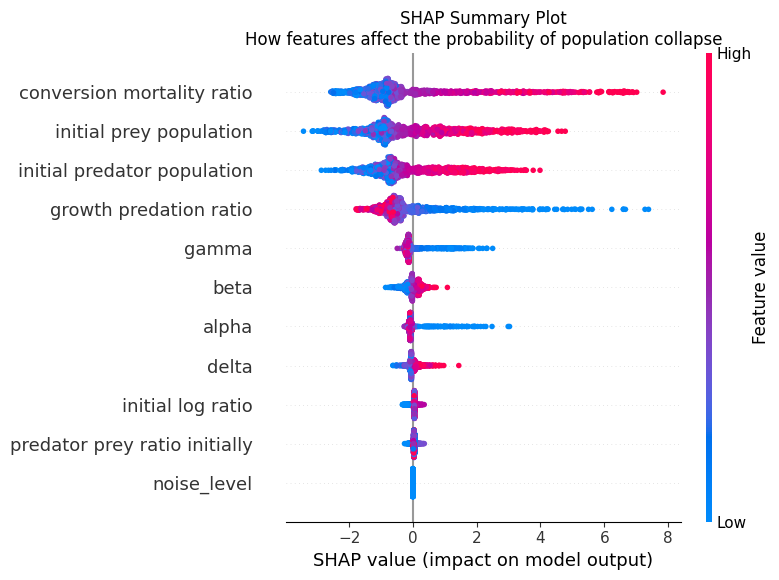

In [ ]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP explainer for the Gradient Boosting model.
#    TreeExplainer is optimized for tree-based models like Gradient Boosting.
explainer = shap.TreeExplainer(gbc)

# 2. Calculate SHAP values for the test dataset.
#    These values show how much each feature contributes to the model's prediction for each instance.
shap_values = explainer.shap_values(x_test)

# For binary classification with TreeExplainer, shap_values usually directly
# represents the SHAP values for the positive class (class 1) as a 2D array.
# The previous line `shap_class1 = shap_values[1]` was incorrectly extracting a single row.

# 3. Create a new figure for the plot.
plt.figure(figsize=(10, 7))

# 4. Generate the SHAP summary plot.
#    This plot visualizes the impact of each feature on the model's output.
shap.summary_plot(shap_values, x_test, show=False)

# 5. Add a title to the plot.
plt.title("SHAP Summary Plot\nHow features affect the probability of population collapse")

# 6. Adjust the plot layout to prevent labels from overlapping.
plt.tight_layout()

# 7. Save the plot as a PNG image.
plt.savefig("shap_summary_gradient_boosting.png", dpi=150, bbox_inches="tight")

# 8. Display the plot.
plt.show()

/tmp/ipython-input-3202089219.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, x_test, plot_type="bar", show=False)


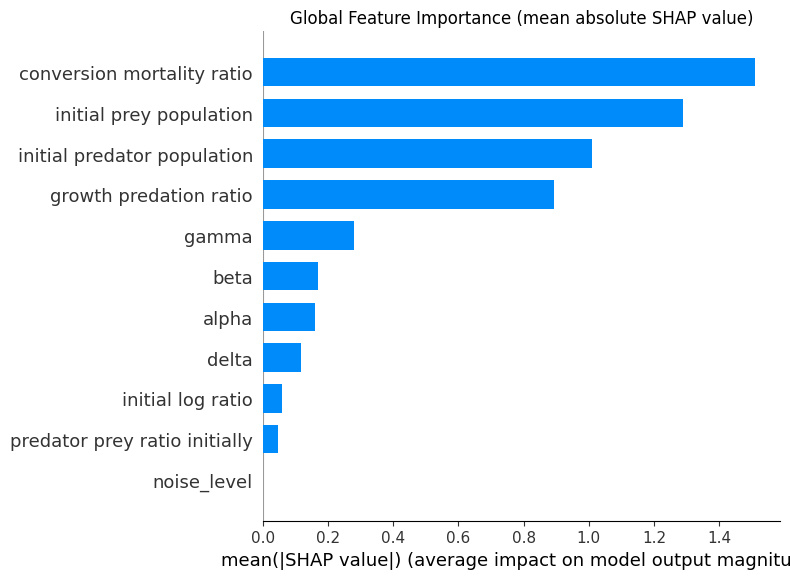

In [ ]:
shap.summary_plot(shap_values, x_test, plot_type="bar", show=False)
plt.title("Global Feature Importance (mean absolute SHAP value)")
plt.tight_layout()
plt.show()

# SHAP waterfall plot showing 5 indexes

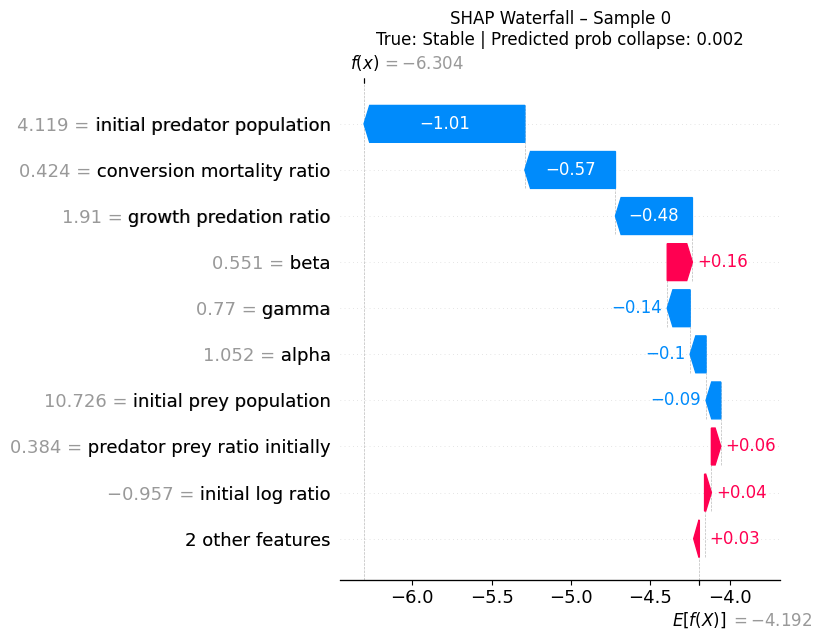

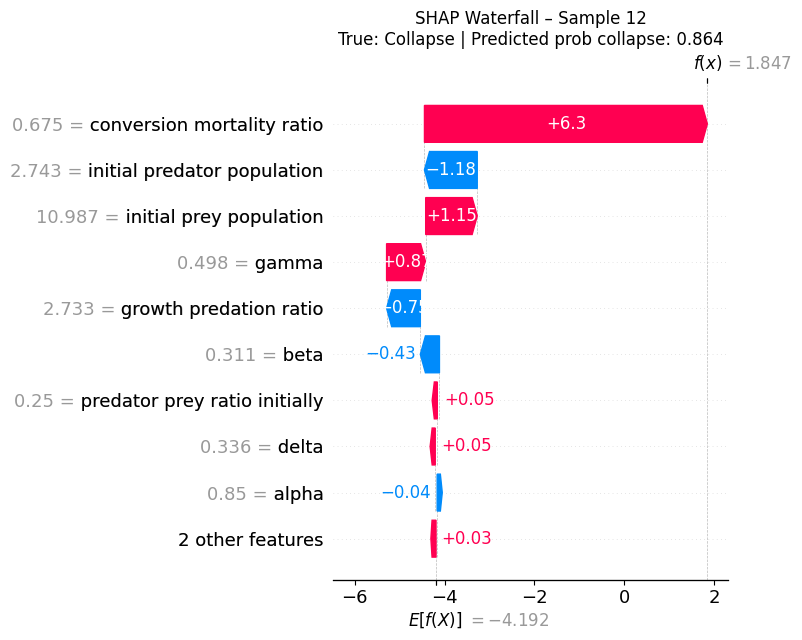

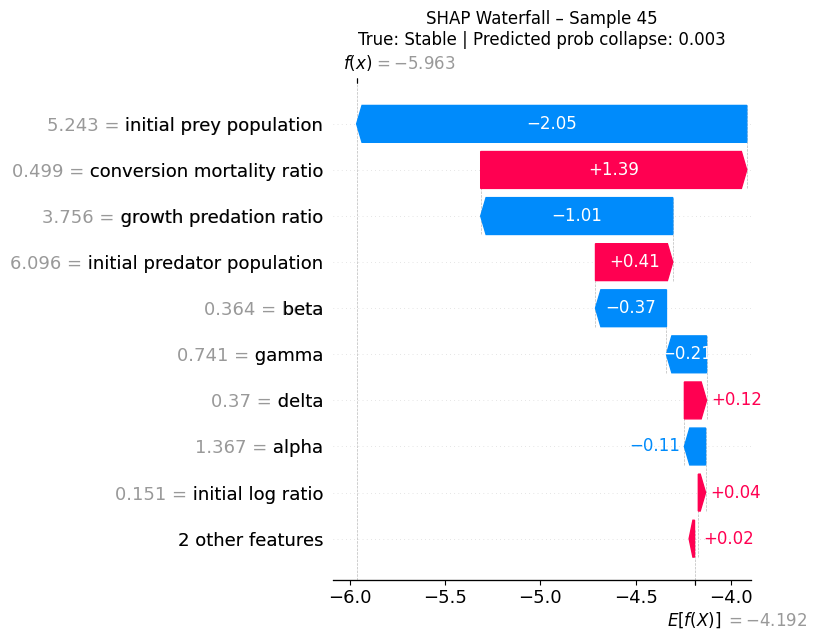

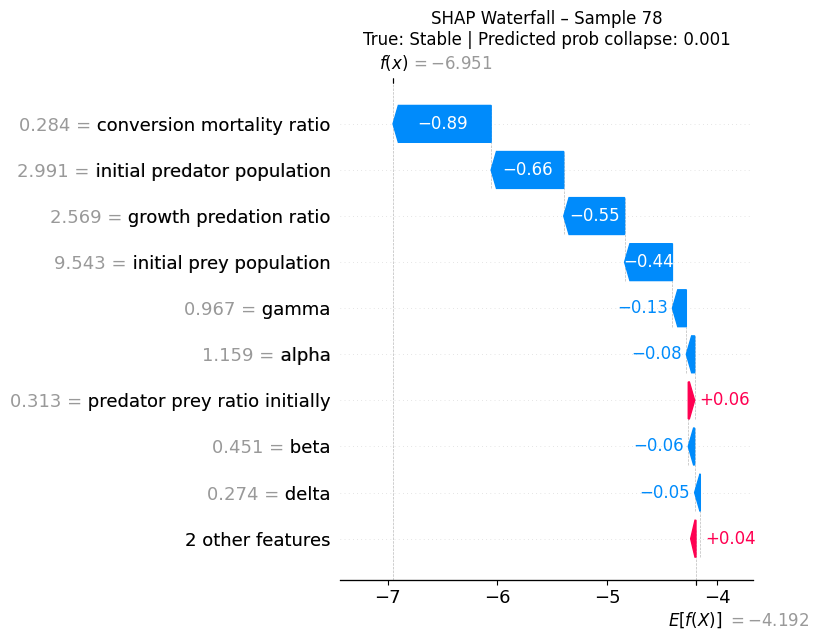

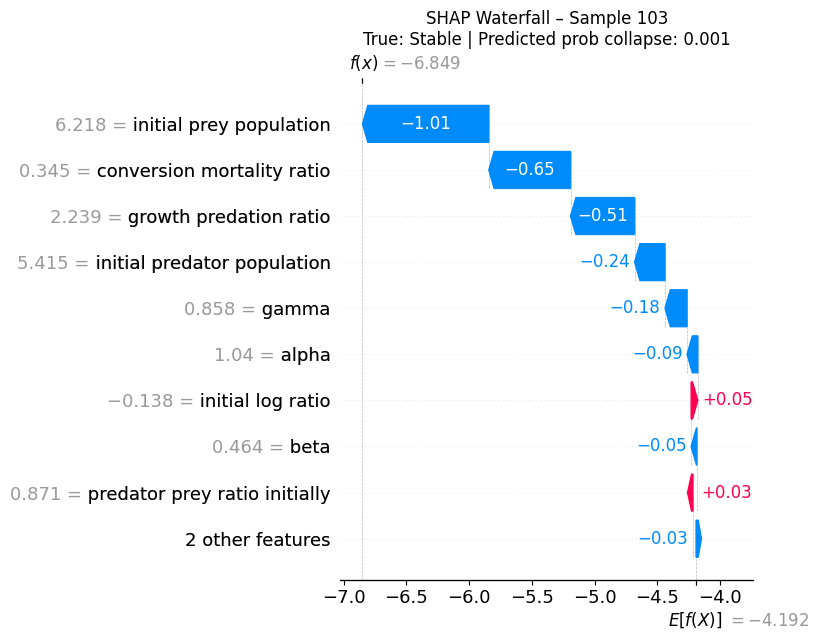

In [ ]:
# For collapse class (class 1)
shap_values_collapse = shap_values[1] if isinstance(shap_values, list) else shap_values

#Sort by predicted probability
probs = gbc.predict_proba(x_test)[:, 1]

selected_indices = [0, 12, 45, 78, 103]

for i in selected_indices:
    # Get true label and predicted probability for context
    true_label = y_test.iloc[i] if hasattr(y_test, 'iloc') else y_test[i]
    pred_prob = gbc.predict_proba(x_test.iloc[[i]])[0, 1]

    plt.figure(figsize=(10, 6))

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_collapse[i],
            base_values=explainer.expected_value,
            data=x_test.iloc[i],
            feature_names=x_test.columns.tolist()
        ),
        max_display=10,
        show=False
    )

    plt.title(f"SHAP Waterfall – Sample {i}\n"
              f"True: {'Collapse' if true_label == 1 else 'Stable'} | "
              f"Predicted prob collapse: {pred_prob:.3f}")

    plt.tight_layout()
    plt.show()